## Step 0 - Environment Setup
### Install required packages


In [1]:
# Install exact versions used in this project
%pip install -q pandas==2.2.2 numpy==1.26.4 scikit-learn==1.5.1 scipy==1.11.4 xgboost==2.0.3 joblib==1.4.2 matplotlib==3.8.4 seaborn==0.13.2 shap==0.46.0


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 1 - Imports and Global Settings
### Import libraries and configure warning/plot style


In [2]:
from __future__ import annotations

import json
from pathlib import Path
from datetime import datetime
import warnings

import joblib
import numpy as np
import pandas as pd

import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns
import shap

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
np.random.seed(42)


c:\Users\Shimar Ahamed\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2 - Path Setup
### Auto-detect project root and create output folders


In [3]:
# Auto-detect project and data paths (works in Colab and local Jupyter)
FILENAME = "Kaggle_Vegetables_fruit_prices_with_climate_130000_2020_to_2025.csv"

candidates = [Path("/content/FarmLink"), Path.cwd(), *Path.cwd().parents]
resolved = None
tried = []

for base in candidates:
    for ml_candidate in [base / "ml", base]:
        csv_candidate = ml_candidate / "data" / "raw" / FILENAME
        tried.append(str(csv_candidate))
        if csv_candidate.exists():
            ML_DIR = ml_candidate
            RAW_CSV = csv_candidate
            PROJECT_ROOT = ml_candidate.parent if ml_candidate.name == "ml" else ml_candidate
            resolved = True
            break
    if resolved:
        break

if not resolved:
    tried_preview = "\n".join(tried[:10])
    raise FileNotFoundError(
        "Raw CSV not found. Checked paths like:\n"
        f"{tried_preview}\n\n"
        "Place the file in ml/data/raw/ or update FILENAME/path in this cell."
    )

DATA_DIR = ML_DIR / "data"
processed_dir = DATA_DIR / "processed"
outputs_dir = DATA_DIR / "outputs"
models_dir = DATA_DIR / "models"
plots_dir = DATA_DIR / "plots"

for d in [processed_dir, outputs_dir, models_dir, plots_dir]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("ML dir:", ML_DIR)
print("Raw CSV:", RAW_CSV)


Project root: c:\Users\Shimar Ahamed\Desktop\FarmLink
ML dir: c:\Users\Shimar Ahamed\Desktop\FarmLink\ml
Raw CSV: c:\Users\Shimar Ahamed\Desktop\FarmLink\ml\data\raw\Kaggle_Vegetables_fruit_prices_with_climate_130000_2020_to_2025.csv


## Step 3 - Helper Functions (Metrics + Utilities)
### Define reusable functions used in later pipeline steps


In [4]:
def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)


def regression_metrics(y_true, y_pred) -> dict:
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mape_val = float(mape(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    return {
        "MAE_LKR": round(mae, 2),
        "RMSE_LKR": round(rmse, 2),
        "MAPE_Percent": round(mape_val, 2),
        "R_Squared": round(r2, 3),
    }


def safe_float(x, default=np.nan):
    try:
        return float(x)
    except Exception:
        return default


def find_column_by_keyword(columns: list[str], keyword: str) -> str:
    for c in columns:
        if keyword.lower() in c.lower():
            return c
    raise ValueError(f"Could not find column containing keyword: {keyword}")


## Step 4 - Load Raw Data
### Read the CSV and inspect structure


In [5]:
# Load raw dataset
df_raw = pd.read_csv(RAW_CSV, encoding="latin1", low_memory=False)

print("Raw shape:", df_raw.shape)
print("Sample columns:", df_raw.columns.tolist()[:15])
df_raw.head(3)


Raw shape: (130000, 10)
Sample columns: ['Date', 'Region', 'Temperature (°C)', 'Rainfall (mm)', 'Humidity (%)', 'Crop Yield Impact Score', 'fruit_Commodity', 'fruit_Price per Unit (LKR/kg)', 'vegitable_Commodity', 'vegitable_Price per Unit (LKR/kg)']


,Date,Region,Temperature (°C),Rainfall (mm),Humidity (%),Crop Yield Impact Score,fruit_Commodity,fruit_Price per Unit (LKR/kg),vegitable_Commodity,vegitable_Price per Unit (LKR/kg)
0,1/1/2020,Ampara,34.4,384.0,69.3,1.67,Banana,282.26,Winged Bean,376.43
1,1/1/2020,Anuradhapura,33.0,21.7,63.5,1.64,Banana,230.28,Winged Bean,210.15
2,1/1/2020,Badulla,35.7,121.8,73.5,1.73,Banana,317.02,Winged Bean,362.29


## Step 5 - Data Cleaning and Column Standardization
### Keep required columns, rename to safe names, convert types, and filter years


In [6]:
# Find climate columns robustly (header encoding may vary)
temp_raw_col = find_column_by_keyword(df_raw.columns.tolist(), "temperature")
rain_raw_col = find_column_by_keyword(df_raw.columns.tolist(), "rainfall")
humidity_raw_col = find_column_by_keyword(df_raw.columns.tolist(), "humidity")

keep_cols = [
    "Date",
    "Region",
    temp_raw_col,
    rain_raw_col,
    humidity_raw_col,
    "vegitable_Commodity",
    "vegitable_Price per Unit (LKR/kg)",
]

missing = [c for c in keep_cols if c not in df_raw.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

# Standard internal names (ASCII-safe)
df = df_raw[keep_cols].copy()
df.columns = [
    "Date",
    "Region",
    "Temperature_C",
    "Rainfall_mm",
    "Humidity_pct",
    "Commodity",
    "Price",
]

# Clean text fields
df["Region"] = df["Region"].astype(str).str.strip()
df["Commodity"] = df["Commodity"].astype(str).str.strip()

# Convert numeric columns
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Temperature_C"] = pd.to_numeric(df["Temperature_C"], errors="coerce")
df["Rainfall_mm"] = pd.to_numeric(df["Rainfall_mm"], errors="coerce")
df["Humidity_pct"] = pd.to_numeric(df["Humidity_pct"], errors="coerce")

# Parse date
df["Date"] = pd.to_datetime(df["Date"], errors="coerce", dayfirst=False)

# Keep valid rows: date, identifiers, positive price, and year range 2020-2024
df = df.dropna(subset=["Date", "Region", "Commodity", "Price"]).copy()
df = df[(df["Date"].dt.year.between(2020, 2024)) & (df["Price"] > 0)].copy()

print("Cleaned daily shape:", df.shape)
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
df.head(3)


Cleaned daily shape: (129999, 7)
Date range: 2020-01-01 to 2024-12-31


,Date,Region,Temperature_C,Rainfall_mm,Humidity_pct,Commodity,Price
0,2020-01-01,Ampara,34.4,384.0,69.3,Winged Bean,376.43
1,2020-01-01,Anuradhapura,33.0,21.7,63.5,Winged Bean,210.15
2,2020-01-01,Badulla,35.7,121.8,73.5,Winged Bean,362.29


## Step 6 - Weekly Aggregation and Feature Engineering
### Aggregate to weekly level and create calendar features


In [7]:
# Monday as week start
# This creates the true weekly dataset used by the model

df["WeekStart"] = df["Date"] - pd.to_timedelta(df["Date"].dt.weekday, unit="D")
df["WeekStart"] = pd.to_datetime(df["WeekStart"]).dt.normalize()

weekly = (
    df.groupby(["WeekStart", "Region", "Commodity"], as_index=False)
    .agg(
        {
            "Price": "mean",
            "Temperature_C": "mean",
            "Rainfall_mm": "mean",
            "Humidity_pct": "mean",
        }
    )
    .sort_values(["Region", "Commodity", "WeekStart"])
    .reset_index(drop=True)
)

# Calendar features
weekly["Year"] = weekly["WeekStart"].dt.year
weekly["Month"] = weekly["WeekStart"].dt.month
weekly["WeekOfYear"] = weekly["WeekStart"].dt.isocalendar().week.astype(int)
weekly["DayOfWeek"] = weekly["WeekStart"].dt.dayofweek
weekly["DayOfYear"] = weekly["WeekStart"].dt.dayofyear

# Climate imputation strategy
# 1) by Region + WeekOfYear
# 2) by Region median
# 3) global median
for col in ["Temperature_C", "Rainfall_mm", "Humidity_pct"]:
    weekly[col] = weekly.groupby(["Region", "WeekOfYear"])[col].transform(lambda s: s.fillna(s.median()))
    weekly[col] = weekly.groupby("Region")[col].transform(lambda s: s.fillna(s.median()))
    weekly[col] = weekly[col].fillna(weekly[col].median())

# Save processed weekly data
weekly.to_csv(processed_dir / "final_vegetables_clean_weekly_2020_2024.csv", index=False)

print("Weekly dataset shape:", weekly.shape)
print("Unique regions:", weekly["Region"].nunique())
print("Unique commodities:", weekly["Commodity"].nunique())
weekly.head(3)


Weekly dataset shape: (129999, 12)
Unique regions: 25
Unique commodities: 20


,WeekStart,Region,Commodity,Price,Temperature_C,Rainfall_mm,Humidity_pct,Year,Month,WeekOfYear,DayOfWeek,DayOfYear
0,2019-12-30,Ampara,Asiatic Pennywort,223.05,34.4,384.0,69.3,2019,12,1,0,364
1,2020-01-06,Ampara,Asiatic Pennywort,116.48,23.3,146.8,56.5,2020,1,2,0,6
2,2020-01-13,Ampara,Asiatic Pennywort,143.67,37.4,9.3,53.9,2020,1,3,0,13


## Step 7 - Exploratory Data Analysis (EDA)
### Generate and save core plots for understanding and presentation


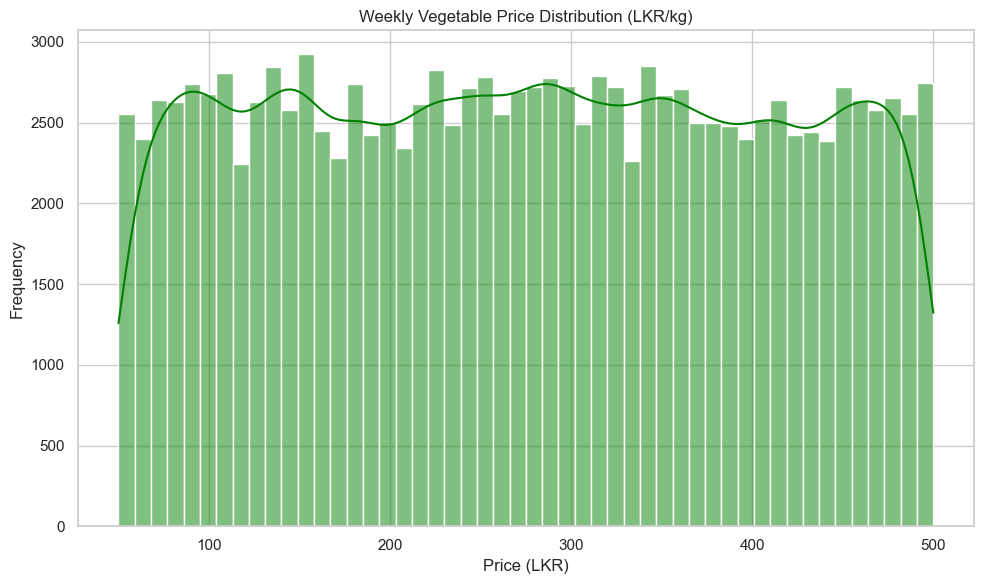

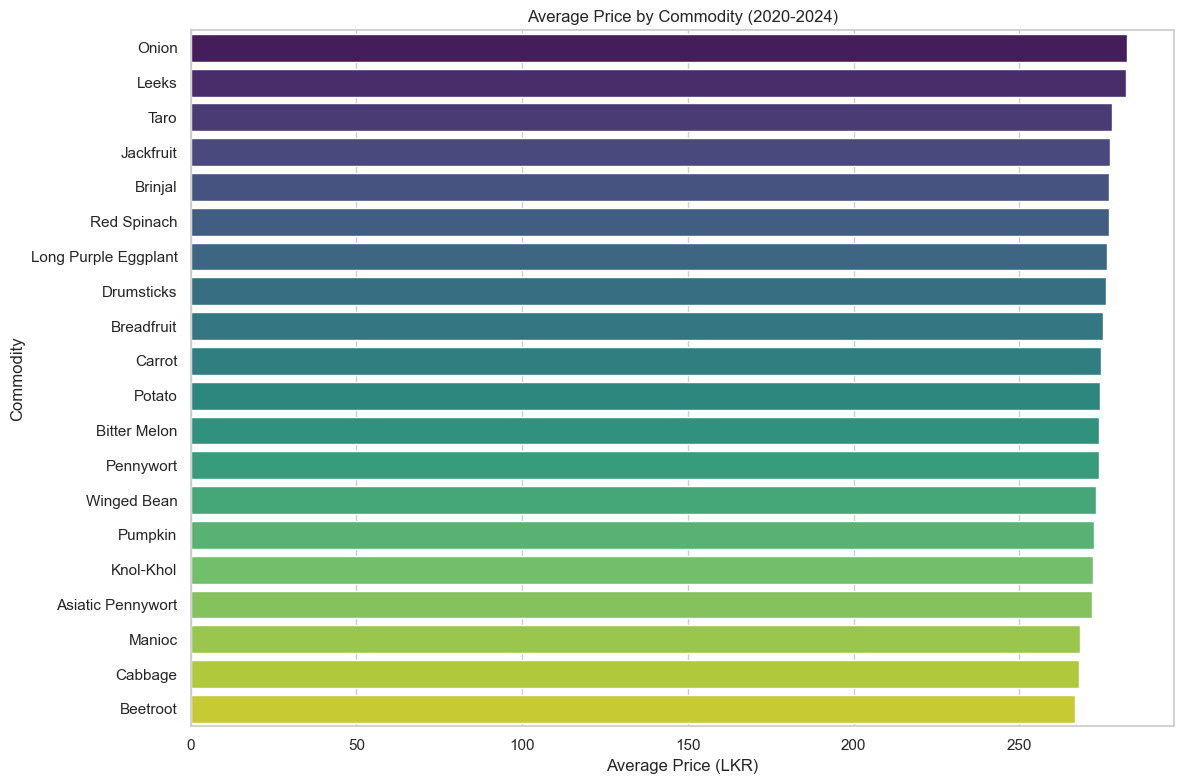

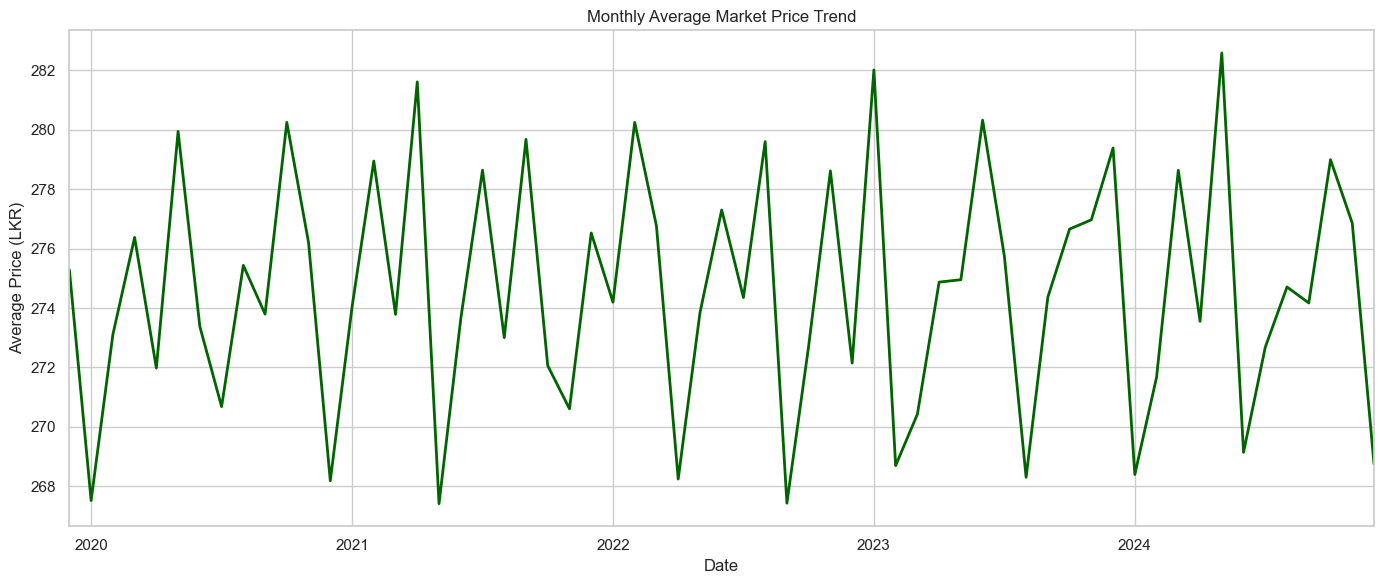

EDA plots saved in: c:\Users\Shimar Ahamed\Desktop\FarmLink\ml\data\plots


In [8]:
# 1) Price distribution
plt.figure(figsize=(10, 6))
sns.histplot(weekly["Price"], bins=50, kde=True, color="green")
plt.title("Weekly Vegetable Price Distribution (LKR/kg)")
plt.xlabel("Price (LKR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(plots_dir / "01_price_distribution.png", dpi=300)
plt.show()
plt.close()

# 2) Average price by commodity
avg_price = weekly.groupby("Commodity")["Price"].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x=avg_price.values, y=avg_price.index, palette="viridis")
plt.title("Average Price by Commodity (2020-2024)")
plt.xlabel("Average Price (LKR)")
plt.ylabel("Commodity")
plt.tight_layout()
plt.savefig(plots_dir / "02_avg_price_by_commodity.png", dpi=300)
plt.show()
plt.close()

# 3) Monthly average trend
monthly = weekly.set_index("WeekStart").resample("ME")["Price"].mean()
plt.figure(figsize=(14, 6))
monthly.plot(color="darkgreen", linewidth=2)
plt.title("Monthly Average Market Price Trend")
plt.xlabel("Date")
plt.ylabel("Average Price (LKR)")
plt.tight_layout()
plt.savefig(plots_dir / "03_monthly_price_trend.png", dpi=300)
plt.show()
plt.close()

print("EDA plots saved in:", plots_dir)


## Step 8 - Time-Based Train/Test Split
### Train: 2020-2023 | Test: 2024


In [9]:
train_df = weekly[weekly["Year"].between(2020, 2023)].copy()
test_df = weekly[weekly["Year"].eq(2024)].copy()

if train_df.empty or test_df.empty:
    raise ValueError("Train or test split is empty. Check dataset year coverage.")

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))


Train rows: 103601
Test rows: 26042


## Step 9 - Feature Matrix Construction and One-Hot Encoding
### Build model inputs and align train/test columns


In [10]:
feature_cols = [
    "Year",
    "Month",
    "WeekOfYear",
    "DayOfWeek",
    "DayOfYear",
    "Temperature_C",
    "Rainfall_mm",
    "Humidity_pct",
    "Region",
    "Commodity",
]

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

X_train = pd.get_dummies(X_train, columns=["Region", "Commodity"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["Region", "Commodity"], drop_first=True)

# Ensure same feature space for test
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df["Price"].astype(float).copy()
y_test = test_df["Price"].astype(float).copy()

feature_columns = list(X_train.columns)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Number of model features:", len(feature_columns))


X_train shape: (103601, 51)
X_test shape: (26042, 51)
Number of model features: 51


## Step 10 - Build and Train XGBoost (Evaluation Model)
### Train on 2020-2023 data only


In [11]:
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror",
    tree_method="hist",
)

model.fit(X_train, y_train)
print("Evaluation model training complete.")


Evaluation model training complete.


## Step 11 - Evaluate Model on 2024 Holdout
### Calculate MAE, RMSE, MAPE, and R?


In [12]:
pred_test = model.predict(X_test)
metrics = regression_metrics(y_test, pred_test)

print("Evaluation Metrics (2024 Holdout):")
print(json.dumps(metrics, indent=2))


Evaluation Metrics (2024 Holdout):
{
  "MAE_LKR": 22.32,
  "RMSE_LKR": 32.87,
  "MAPE_Percent": 12.73,
  "R_Squared": 0.936
}


## Step 12 - Evaluation Visualizations and SHAP Explainability
### Save actual-vs-predicted, feature importance, and SHAP plots


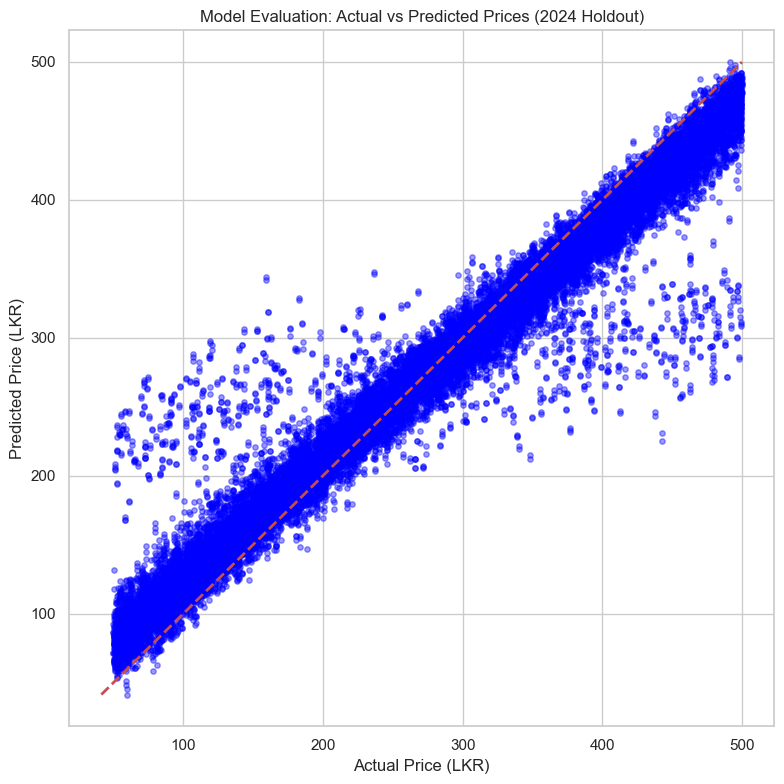

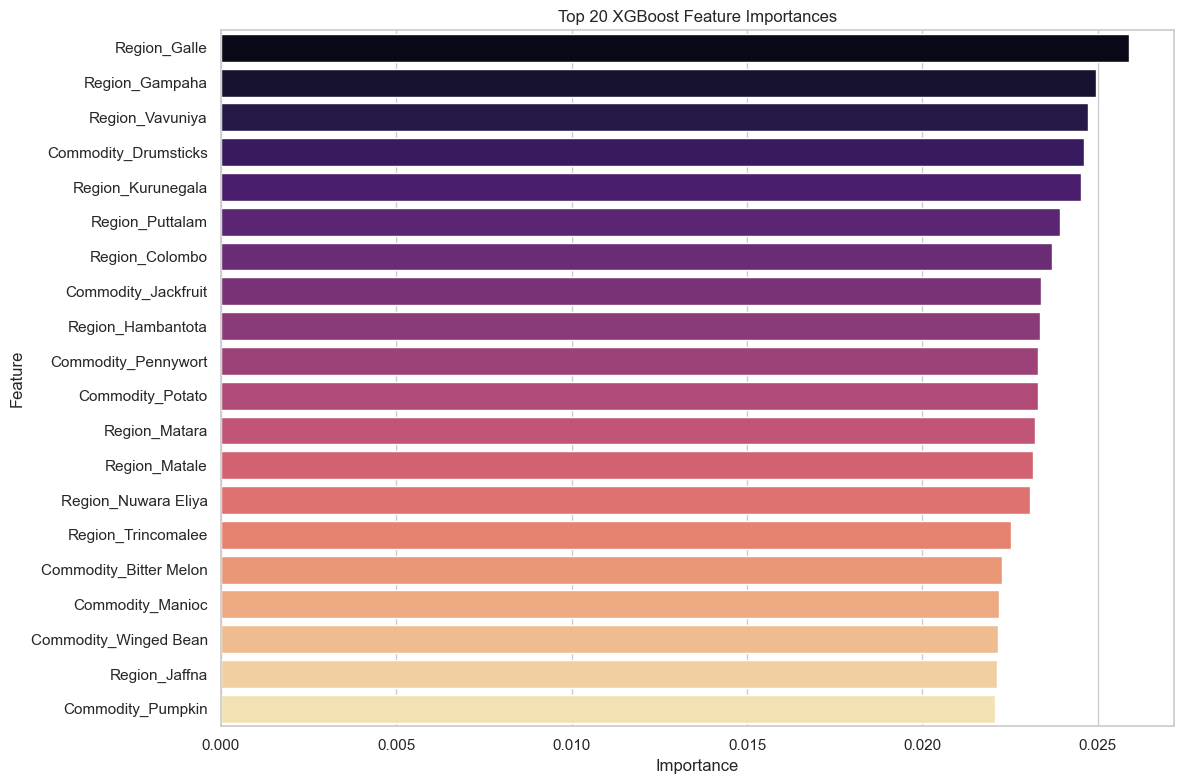

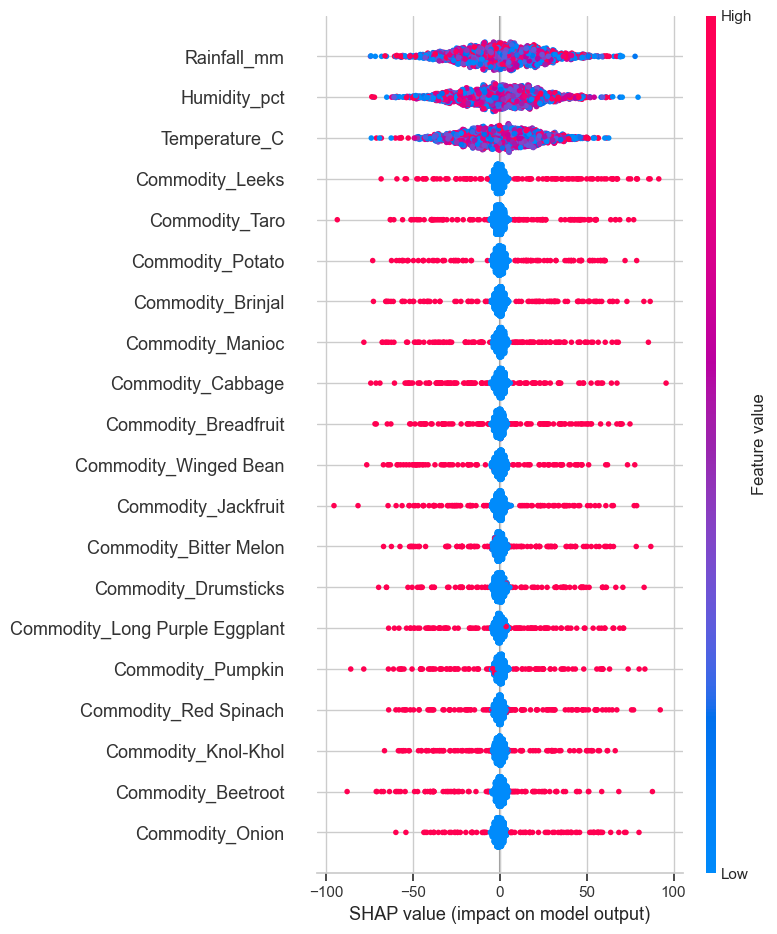

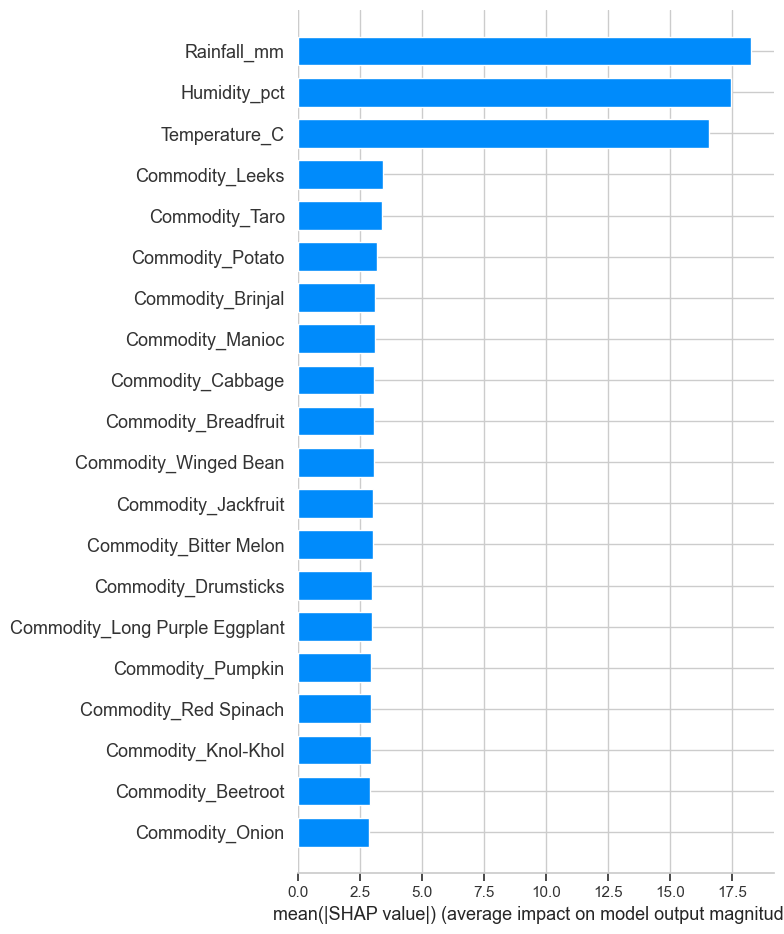

Evaluation and SHAP plots saved in: c:\Users\Shimar Ahamed\Desktop\FarmLink\ml\data\plots


In [13]:
# Actual vs Predicted
plt.figure(figsize=(8, 8))
plt.scatter(y_test, pred_test, alpha=0.4, color="blue", s=15)
mn = min(np.min(y_test), np.min(pred_test))
mx = max(np.max(y_test), np.max(pred_test))
plt.plot([mn, mx], [mn, mx], "r--", linewidth=2)
plt.title("Model Evaluation: Actual vs Predicted Prices (2024 Holdout)")
plt.xlabel("Actual Price (LKR)")
plt.ylabel("Predicted Price (LKR)")
plt.tight_layout()
plt.savefig(plots_dir / "04_actual_vs_predicted.png", dpi=300)
plt.show()
plt.close()

# Top-20 feature importance
imp_df = pd.DataFrame({"feature": feature_columns, "importance": model.feature_importances_})
imp_df = imp_df.sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(data=imp_df, x="importance", y="feature", palette="magma")
plt.title("Top 20 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(plots_dir / "05_feature_importance_top20.png", dpi=300)
plt.show()
plt.close()

# SHAP summary plots
sample_size = min(2000, len(X_test))
if sample_size > 0:
    X_sample = X_test.sample(n=sample_size, random_state=42)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    plt.figure()
    shap.summary_plot(shap_values, X_sample, show=False)
    plt.tight_layout()
    plt.savefig(plots_dir / "06_shap_summary_plot.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    plt.figure()
    shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
    plt.tight_layout()
    plt.savefig(plots_dir / "07_shap_bar_plot.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

print("Evaluation and SHAP plots saved in:", plots_dir)


## Step 13 - Save Evaluation Artifacts
### Save holdout predictions and evaluation-stage model


In [14]:
# Save test predictions
eval_df = test_df[["WeekStart", "Region", "Commodity", "Price"]].copy()
eval_df["PredictedPrice"] = pred_test
eval_df.to_csv(outputs_dir / "final_test_predictions_2024.csv", index=False)

# Save model trained on 2020-2023
joblib.dump(model, models_dir / "final_xgb_vegetable_model_eval_2020_2023.pkl")

print("Saved:")
print("-", outputs_dir / "final_test_predictions_2024.csv")
print("-", models_dir / "final_xgb_vegetable_model_eval_2020_2023.pkl")


Saved:
- c:\Users\Shimar Ahamed\Desktop\FarmLink\ml\data\outputs\final_test_predictions_2024.csv
- c:\Users\Shimar Ahamed\Desktop\FarmLink\ml\data\models\final_xgb_vegetable_model_eval_2020_2023.pkl


## Step 14 - Retrain Final Model on Full History
### Train final production model on 2020-2024


In [15]:
full_df = weekly[weekly["Year"].between(2020, 2024)].copy()

full_feature_cols = [
    "Year",
    "Month",
    "WeekOfYear",
    "DayOfWeek",
    "DayOfYear",
    "Temperature_C",
    "Rainfall_mm",
    "Humidity_pct",
    "Region",
    "Commodity",
]

X_full = full_df[full_feature_cols].copy()
X_full = pd.get_dummies(X_full, columns=["Region", "Commodity"], drop_first=True)
X_full = X_full.reindex(columns=feature_columns, fill_value=0)
y_full = full_df["Price"].astype(float).copy()

final_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror",
    tree_method="hist",
)

final_model.fit(X_full, y_full)
joblib.dump(final_model, models_dir / "final_xgb_vegetable_model_final.pkl")

print("Final model trained and saved:", models_dir / "final_xgb_vegetable_model_final.pkl")


Final model trained and saved: c:\Users\Shimar Ahamed\Desktop\FarmLink\ml\data\models\final_xgb_vegetable_model_final.pkl


## Step 15 - Build 2026 Weekly Forecast Feature Frame
### Create future calendar rows and attach historical climate averages


In [16]:
# Historical weekly climate profile from full data
weekly_climate = full_df.groupby(["Region", "WeekOfYear"], as_index=False)[
    ["Temperature_C", "Rainfall_mm", "Humidity_pct"]
].mean()

regions = sorted(full_df["Region"].unique().tolist())
commodities = sorted(full_df["Commodity"].unique().tolist())

forecast_dates = pd.date_range("2026-01-05", "2026-12-28", freq="W-MON")
rows = []

for region in regions:
    for commodity in commodities:
        for d in forecast_dates:
            rows.append(
                {
                    "WeekStart": d,
                    "Region": region,
                    "Commodity": commodity,
                    "Year": d.year,
                    "Month": d.month,
                    "WeekOfYear": int(d.isocalendar().week),
                    "DayOfWeek": d.dayofweek,
                    "DayOfYear": d.timetuple().tm_yday,
                }
            )

fdf = pd.DataFrame(rows)

# Attach region-week climate
fdf = fdf.merge(weekly_climate, on=["Region", "WeekOfYear"], how="left")

# Fallback: global weekly climate when region-week is missing
if fdf[["Temperature_C", "Rainfall_mm", "Humidity_pct"]].isna().any().any():
    overall_weekly = weekly_climate.groupby("WeekOfYear", as_index=False)[
        ["Temperature_C", "Rainfall_mm", "Humidity_pct"]
    ].mean()

    fdf = fdf.merge(overall_weekly, on="WeekOfYear", how="left", suffixes=("", "_global"))

    for col in ["Temperature_C", "Rainfall_mm", "Humidity_pct"]:
        fdf[col] = fdf[col].fillna(fdf[f"{col}_global"])
        fdf.drop(columns=[f"{col}_global"], inplace=True)

print("Future frame shape:", fdf.shape)
fdf.head(3)


Future frame shape: (26000, 11)


,WeekStart,Region,Commodity,Year,Month,WeekOfYear,DayOfWeek,DayOfYear,Temperature_C,Rainfall_mm,Humidity_pct
0,2026-01-05,Ampara,Asiatic Pennywort,2026,1,2,0,5,27.037000,185.993000,64.065000
1,2026-01-12,Ampara,Asiatic Pennywort,2026,1,3,0,12,31.693000,133.589000,65.282000
2,2026-01-19,Ampara,Asiatic Pennywort,2026,1,4,0,19,26.830208,227.828125,72.754167


## Step 16 - Forecast Prediction + XAI Contributions
### Encode future frame, predict 2026 prices, and compute per-row contributions


In [17]:
# Encode future features exactly like training
base_future = fdf[
    [
        "Year", "Month", "WeekOfYear", "DayOfWeek", "DayOfYear",
        "Temperature_C", "Rainfall_mm", "Humidity_pct", "Region", "Commodity"
    ]
].copy()

forecast_enc = pd.get_dummies(base_future, columns=["Region", "Commodity"], drop_first=True)
forecast_enc = forecast_enc.reindex(columns=feature_columns, fill_value=0)

# Predict with final model
preds = final_model.predict(forecast_enc)
fdf["yhat_lkr"] = preds

# XGBoost contribution values for explanation building
contribs = final_model.get_booster().predict(
    xgb.DMatrix(forecast_enc, feature_names=feature_columns),
    pred_contribs=True,
    approx_contribs=True,
)

# Heuristic interval width from holdout MAE
ci = 1.5 * metrics["MAE_LKR"]

print("Encoded future shape:", forecast_enc.shape)
print("Contribution matrix shape:", contribs.shape)


Encoded future shape: (26000, 51)
Contribution matrix shape: (26000, 52)


## Step 17 - Farmer-Friendly Explanation Builder
### Convert top contribution features to plain-language market explanations


In [18]:
def top_contrib_features(feature_columns: list[str], contrib_row: np.ndarray, top_k=6):
    vals = contrib_row[:-1]  # last element is bias term
    idx = np.argsort(np.abs(vals))[::-1][:top_k]
    return [(feature_columns[i], float(vals[i])) for i in idx]


def farmer_explanation_from_contribs(top_feats: list[tuple[str, float]], region: str | None = None) -> str:
    time_keys = {"Year", "Month", "WeekOfYear", "DayOfWeek", "DayOfYear"}
    climate_keys = {"Temperature_C", "Rainfall_mm", "Humidity_pct"}

    time_effect = 0.0
    climate_effect = 0.0
    location_effect = 0.0
    veg_effect = 0.0

    for name, val in top_feats:
        if name in time_keys:
            time_effect += val
        elif name in climate_keys:
            climate_effect += val
        elif name.startswith("Region_"):
            location_effect += val
        elif name.startswith("Commodity_"):
            veg_effect += val

    def phrase(effect: float, topic: str):
        if abs(effect) < 1.0:
            return None
        if effect > 0:
            return f"{topic} may push the price up by around Rs {abs(effect):.0f}"
        return f"{topic} may push the price down by around Rs {abs(effect):.0f}"

    location_topic = f"Market conditions in {region}" if region else "Market conditions in this area"

    parts = [
        phrase(veg_effect, "The usual market value of this vegetable"),
        phrase(location_effect, location_topic),
        phrase(time_effect, "Seasonal demand this week"),
        phrase(climate_effect, "This week's weather"),
    ]
    parts = [p for p in parts if p]

    if not parts:
        return "Prices are expected to stay fairly stable this week."

    return "Market drivers: " + ", and ".join(parts[:3]) + "."

print("Farmer explanation helper ready.")


Farmer explanation helper ready.


## Step 18 - Build Final Forecast JSON/CSV + Metadata + Summary
### Export all final artifacts for backend and reporting


In [19]:
pairs_out = []

for (region, commodity), group in fdf.groupby(["Region", "Commodity"], sort=True):
    forecasts = []
    group = group.sort_values("WeekStart")

    for i in group.index:
        pred = float(group.loc[i, "yhat_lkr"])
        top_feats = top_contrib_features(feature_columns, contribs[i], top_k=6)

        forecasts.append(
            {
                "ds": group.loc[i, "WeekStart"].strftime("%Y-%m-%d"),
                "yhat_lkr": round(pred, 2),
                "yhat_lower_lkr": round(max(0.0, pred - ci), 2),
                "yhat_upper_lkr": round(pred + ci, 2),
                "climate_assumed": {
                    "temperature": round(safe_float(group.loc[i, "Temperature_C"]), 2),
                    "rainfall": round(safe_float(group.loc[i, "Rainfall_mm"]), 2),
                    "humidity": round(safe_float(group.loc[i, "Humidity_pct"]), 2),
                },
                "xai_farmer": {
                    "explanation": farmer_explanation_from_contribs(top_feats, region=region)
                },
            }
        )

    pairs_out.append(
        {
            "region": region,
            "commodity": commodity,
            "forecast": forecasts,
        }
    )

# Final forecast JSON structure
output = {
    "generated_at": datetime.now().isoformat(timespec="seconds"),
    "resolution": "Weekly",
    "model": "XGBoost Weekly Calendar-Climate Forecast Model with XAI",
    "notes": {
        "evaluation_period": "2024 holdout",
        "final_training_period": "2020-2024",
        "future_forecast_method": "Direct weekly forecast",
        "future_external_variables": "Estimated from historical region-week averages",
        "prediction_interval": "Heuristic interval based on 1.5 x MAE",
    },
    "test_metrics": metrics,
    "pairs": pairs_out,
}

# Save forecast files
forecast_json = outputs_dir / "final_forecasts_2026_weekly_xgb_final.json"
forecast_json.write_text(json.dumps(output, indent=2, ensure_ascii=False), encoding="utf-8")

forecast_csv = fdf.copy()
forecast_csv.rename(columns={"WeekStart": "Date"}, inplace=True)
forecast_csv.to_csv(outputs_dir / "final_forecasts_2026_weekly_xgb_final.csv", index=False)

# Save metadata
meta = {
    "feature_columns": feature_columns,
    "regions": regions,
    "commodities": commodities,
    "test_metrics": metrics,
    "train_period": "2020-2023",
    "test_period": "2024",
    "final_training_period": "2020-2024",
    "forecast_method": "Direct weekly forecast using calendar, climate, region, and commodity features",
    "future_climate_method": "Historical weekly region-wise averages",
    "xai_methods": [
        "XGBoost pred_contribs for farmer-friendly explanations",
        "SHAP for thesis-level global explainability plots",
    ],
}
(models_dir / "xgb_model_meta.json").write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")

# Save summary
summary = {
    "rows_total_weekly": int(len(weekly)),
    "rows_train": int(len(train_df)),
    "rows_test": int(len(test_df)),
    "regions": int(full_df["Region"].nunique()),
    "commodities": int(full_df["Commodity"].nunique()),
    "forecast_pairs": int(len(pairs_out)),
    "forecast_rows_2026": int(len(fdf)),
    "metrics": metrics,
}
(outputs_dir / "training_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")

print("Done. Exported final artifacts.")
print("Forecast JSON:", forecast_json)


Done. Exported final artifacts.
Forecast JSON: c:\Users\Shimar Ahamed\Desktop\FarmLink\ml\data\outputs\final_forecasts_2026_weekly_xgb_final.json


## Step 19 - Final Output Check
### Preview important files and a sample of forecast rows


In [20]:
print("Saved files:")
print("-", processed_dir / "final_vegetables_clean_weekly_2020_2024.csv")
print("-", outputs_dir / "final_test_predictions_2024.csv")
print("-", outputs_dir / "final_forecasts_2026_weekly_xgb_final.csv")
print("-", outputs_dir / "final_forecasts_2026_weekly_xgb_final.json")
print("-", outputs_dir / "training_summary.json")
print("-", models_dir / "final_xgb_vegetable_model_eval_2020_2023.pkl")
print("-", models_dir / "final_xgb_vegetable_model_final.pkl")
print("-", models_dir / "xgb_model_meta.json")

print("\nMetrics:")
print(json.dumps(metrics, indent=2))

forecast_csv.head()


Saved files:
- c:\Users\Shimar Ahamed\Desktop\FarmLink\ml\data\processed\final_vegetables_clean_weekly_2020_2024.csv
- c:\Users\Shimar Ahamed\Desktop\FarmLink\ml\data\outputs\final_test_predictions_2024.csv
- c:\Users\Shimar Ahamed\Desktop\FarmLink\ml\data\outputs\final_forecasts_2026_weekly_xgb_final.csv
- c:\Users\Shimar Ahamed\Desktop\FarmLink\ml\data\outputs\final_forecasts_2026_weekly_xgb_final.json
- c:\Users\Shimar Ahamed\Desktop\FarmLink\ml\data\outputs\training_summary.json
- c:\Users\Shimar Ahamed\Desktop\FarmLink\ml\data\models\final_xgb_vegetable_model_eval_2020_2023.pkl
- c:\Users\Shimar Ahamed\Desktop\FarmLink\ml\data\models\final_xgb_vegetable_model_final.pkl
- c:\Users\Shimar Ahamed\Desktop\FarmLink\ml\data\models\xgb_model_meta.json

Metrics:
{
  "MAE_LKR": 22.32,
  "RMSE_LKR": 32.87,
  "MAPE_Percent": 12.73,
  "R_Squared": 0.936
}


,Date,Region,Commodity,Year,Month,WeekOfYear,DayOfWeek,DayOfYear,Temperature_C,Rainfall_mm,Humidity_pct,yhat_lkr
0,2026-01-05,Ampara,Asiatic Pennywort,2026,1,2,0,5,27.037000,185.993000,64.065000,269.529022
1,2026-01-12,Ampara,Asiatic Pennywort,2026,1,3,0,12,31.693000,133.589000,65.282000,281.557678
2,2026-01-19,Ampara,Asiatic Pennywort,2026,1,4,0,19,26.830208,227.828125,72.754167,288.156006
3,2026-01-26,Ampara,Asiatic Pennywort,2026,1,5,0,26,26.924242,205.395960,81.439394,247.131866
4,2026-02-02,Ampara,Asiatic Pennywort,2026,2,6,0,33,27.221000,182.017000,76.204000,272.948700
